In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
data = pd.read_excel('music_top_LastFM.xlsx')
data.head()

,Unnamed: 0,name,artist,playcount,listeners,duration,url,genres,top_genre
0,0,Stateside + Zara Larsson,PinkPantheress,16644413,1092288,176,https://www.last.fm/music/PinkPantheress/_/Sta...,NaN,NaN
1,1,FATHER (feat. Travis Scott),Kanye West,1112155,277089,171,https://www.last.fm/music/Kanye+West/_/FATHER+...,NaN,NaN
2,2,KING,Kanye West,2065728,387318,126,https://www.last.fm/music/Kanye+West/_/KING,King;trap;outro;Skibidi Toilet;anti semetic,King
3,3,Babydoll,Dominic Fike,23069840,1549379,97,https://www.last.fm/music/Dominic+Fike/_/Babydoll,chill;alternative;pop;indie;alternative pop,chill
4,4,SWIM,BTS,52676285,358110,159,https://www.last.fm/music/BTS/_/SWIM,NaN,NaN


Name - название песни

artist - имя исполнителя/группы

playcount - количество проигрываний песни

listeners - количество слушателей

duration - длительность музыкальной дорожки

url - ссылка на песню

genres - жанры, которые выбрали слушатели

top_genre - топ жанр (самый популярный)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  9999 non-null   int64 
 1   name        9998 non-null   object
 2   artist      9999 non-null   object
 3   playcount   9999 non-null   int64 
 4   listeners   9999 non-null   int64 
 5   duration    9999 non-null   int64 
 6   url         9999 non-null   object
 7   genres      8582 non-null   object
 8   top_genre   8582 non-null   object
dtypes: int64(4), object(5)
memory usage: 703.2+ KB


Classical Music
Country & Folk
Electronic Music
Faith
Hip-Hop
Indie Rock
Jazz
Kids
Latin
Metal
Pop
Punk
R&B
Rock
World Music

Создаем колонку genre_kick, в которой будут лежать названия жанра как в главном датасете kickstarter

In [7]:
genres_list = ['classical music', 'country & folk', 'electronic music', 'faith','hip-hop', 'indie rock', 'jazz', 'kids', 'latin', 'metal', 'pop', 'punk', 'r&b', 'rock', 'world music']

def find_genres(strr):
  if pd.isna(strr):
    return strr
  strr = strr.lower()
  for i in genres_list:
    if strr.count(i):
      return i
  if strr.count('hip hop'):
    return 'hip-hop'
  if strr.count('indie'):
    return 'indie rock'
  if strr.count('classical'):
    return 'classical music'
  if strr.count('country') or strr.count('folk') :
    return 'country & folk'
  if strr.count('electronic'):
    return 'electronic music'
  return None

data['genre_kick'] = data['genres'].apply(find_genres)
data

,Unnamed: 0,name,artist,playcount,listeners,duration,url,genres,top_genre,genre_kick
0,0,Stateside + Zara Larsson,PinkPantheress,16644413,1092288,176,https://www.last.fm/music/PinkPantheress/_/Sta...,NaN,NaN,NaN
1,1,FATHER (feat. Travis Scott),Kanye West,1112155,277089,171,https://www.last.fm/music/Kanye+West/_/FATHER+...,NaN,NaN,NaN
2,2,KING,Kanye West,2065728,387318,126,https://www.last.fm/music/Kanye+West/_/KING,King;trap;outro;Skibidi Toilet;anti semetic,King,None
3,3,Babydoll,Dominic Fike,23069840,1549379,97,https://www.last.fm/music/Dominic+Fike/_/Babydoll,chill;alternative;pop;indie;alternative pop,chill,pop
4,4,SWIM,BTS,52676285,358110,159,https://www.last.fm/music/BTS/_/SWIM,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
9994,9994,on the street (with J. Cole),j-hope,32167631,349187,214,https://www.last.fm/music/j-hope/_/on+the+stre...,MORE;j-hope;JitB;Hip-Hop;Masterpiece,MORE,hip-hop
9995,9995,Lucid Dream,aespa,8183749,401679,0,https://www.last.fm/music/aespa/_/Lucid+Dream,contemporary rnb;rnb;k-pop;alternative rnb;fut...,contemporary rnb,pop
9996,9996,The View Between Villages - Extended,Noah Kahan,2432691,161048,292,https://www.last.fm/music/Noah+Kahan/_/The+Vie...,NaN,NaN,NaN
9997,9997,Sticker,NCT 127,4257357,244450,227,https://www.last.fm/music/NCT+127/_/Sticker,NaN,NaN,NaN


In [8]:
data[pd.isna(data['genre_kick']) & ~(pd.isna(data['genres']))].to_excel("mrr.xlsx")
#детально глянули
data[pd.isna(data['genre_kick']) & ~(pd.isna(data['genres']))]

,Unnamed: 0,name,artist,playcount,listeners,duration,url,genres,top_genre,genre_kick
2,2,KING,Kanye West,2065728,387318,126,https://www.last.fm/music/Kanye+West/_/KING,King;trap;outro;Skibidi Toilet;anti semetic,King,None
31,31,Dracula - JENNIE remix,Tame Impala,2971656,433415,209,https://www.last.fm/music/Tame+Impala/_/Dracul...,buwygfibsara;loonaids;glindas;julia mofada,buwygfibsara,None
42,42,See You Again (feat. Kali Uchis),"Tyler, The Creator",56550315,2523838,180,"https://www.last.fm/music/Tyler,+The+Creator/_...",rap;rnb;Neo-Soul;kali uchis;alternative rnb,rap,None
46,46,American Girls,Harry Styles,2906979,435098,213,https://www.last.fm/music/Harry+Styles/_/Ameri...,soty;julia mofada,soty,None
85,85,BAILE INoLVIDABLE,Bad Bunny,12718948,914181,368,https://www.last.fm/music/Bad+Bunny/_/BAILE+IN...,salsa;instrumental;loud;Reggaeton;spoken,salsa,None
...,...,...,...,...,...,...,...,...,...,...
9950,9950,Room of Fools,FKA twigs,2201469,241452,265,https://www.last.fm/music/FKA+twigs/_/Room+of+...,vocal trance;melodic techno;progressive trance...,vocal trance,None
9951,9951,You Only Live Twice (with Lil Wayne & Rick Ross),Drake,2398243,282819,0,https://www.last.fm/music/Drake/_/You+Only+Liv...,Lil Wayne;Drake;chipmunk soul;rick ross;2021,Lil Wayne,None
9955,9955,Soren,beabadoobee,3013366,276911,241,https://www.last.fm/music/beabadoobee/_/Soren,name,name,None
9970,9970,Love On The Catwalk,Her Words Kill,616713,74659,417,https://www.last.fm/music/Her+Words+Kill/_/Lov...,post-hardcore;emo;emocore;epic;melodic core,post-hardcore,None


In [9]:
data.isna().sum()

,0
Unnamed: 0,0
name,1
artist,0
playcount,0
listeners,0
duration,0
url,0
genres,1417
top_genre,1417
genre_kick,2555


In [10]:
new_data = data[~pd.isna(data['genre_kick'])]
new_data

,Unnamed: 0,name,artist,playcount,listeners,duration,url,genres,top_genre,genre_kick
3,3,Babydoll,Dominic Fike,23069840,1549379,97,https://www.last.fm/music/Dominic+Fike/_/Babydoll,chill;alternative;pop;indie;alternative pop,chill,pop
12,12,Fame Is a Gun,Addison Rae,19199057,1007818,183,https://www.last.fm/music/Addison+Rae/_/Fame+I...,electropop;pop;synthpop;Electroclash;electronic,electropop,pop
16,16,WHERE IS MY HUSBAND!,RAYE,10257310,941931,196,https://www.last.fm/music/RAYE/_/WHERE+IS+MY+H...,pop soul;Big Band;Go-Go;contemporary rnb;motow...,pop soul,pop
24,24,Manchild,Sabrina Carpenter,23753346,1220337,213,https://www.last.fm/music/Sabrina+Carpenter/_/...,pop;rnb;country;synthpop;country pop,pop,pop
27,27,Dracula,Tame Impala,9843306,994319,205,https://www.last.fm/music/Tame+Impala/_/Dracula,psychedelic;synthpop;synth funk;nu-disco;Disco,psychedelic,pop
...,...,...,...,...,...,...,...,...,...,...
9991,9991,Shame,System of a Down,1710960,233301,160,https://www.last.fm/music/System+of+a+Down/_/S...,metal;hard rock;Nu Metal;alternative metal;rap...,metal,metal
9993,9993,13 Beaches,Lana Del Rey,6484287,516977,268,https://www.last.fm/music/Lana+Del+Rey/_/13+Be...,chamber pop;ambient pop;art pop;pop;alternative,chamber pop,pop
9994,9994,on the street (with J. Cole),j-hope,32167631,349187,214,https://www.last.fm/music/j-hope/_/on+the+stre...,MORE;j-hope;JitB;Hip-Hop;Masterpiece,MORE,hip-hop
9995,9995,Lucid Dream,aespa,8183749,401679,0,https://www.last.fm/music/aespa/_/Lucid+Dream,contemporary rnb;rnb;k-pop;alternative rnb;fut...,contemporary rnb,pop


In [11]:
data['genre_kick'].unique()

array([nan, None, 'pop', 'hip-hop', 'metal', 'rock', 'indie rock',
       'latin', 'jazz', 'punk', 'r&b', 'electronic music',
       'country & folk', 'kids', 'classical music'], dtype=object)

<Axes: >

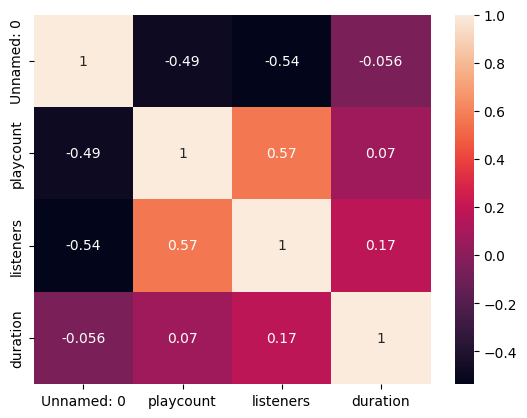

In [12]:
sns.heatmap(new_data.corr(numeric_only = True),  annot=True)

Видим среднюю обратную корреляцию между unnamed(место в рейтинге) и playcount, listeners. Можем сделать вывод, что чем больше прослушиваний и слушателей, тем выше рейтинг у песни.

Также есть корреляция между прослушиваними и слушателями. Здесь все логично, чем больше слушателей, тем больше прослушиваний

Гипотезы:
1. Есть более популярные жанры, которые чаще выходят в топ
2. Чем короче песня, тем больше шансов быть в топе

In [13]:
new_data['genre_kick'].value_counts()

,count
genre_kick,
pop,3733
hip-hop,1139
rock,760
indie rock,625
metal,398
jazz,209
electronic music,172
punk,157
latin,120


In [14]:
new_data.groupby('genre_kick')['playcount'].mean().sort_values(ascending=False)/10000

,playcount
genre_kick,
r&b,1029.717756
pop,926.273280
indie rock,918.620297
rock,879.664955
jazz,796.937185
hip-hop,788.765856
metal,777.210642
punk,759.487669
kids,724.600780


In [15]:
new_data.groupby('genre_kick')['listeners'].mean().sort_values(ascending=False)/10000

,listeners
genre_kick,
rock,90.960136
r&b,86.271508
indie rock,76.401276
punk,75.287780
metal,72.051384
pop,67.915472
hip-hop,66.702113
jazz,62.699937
electronic music,62.612052


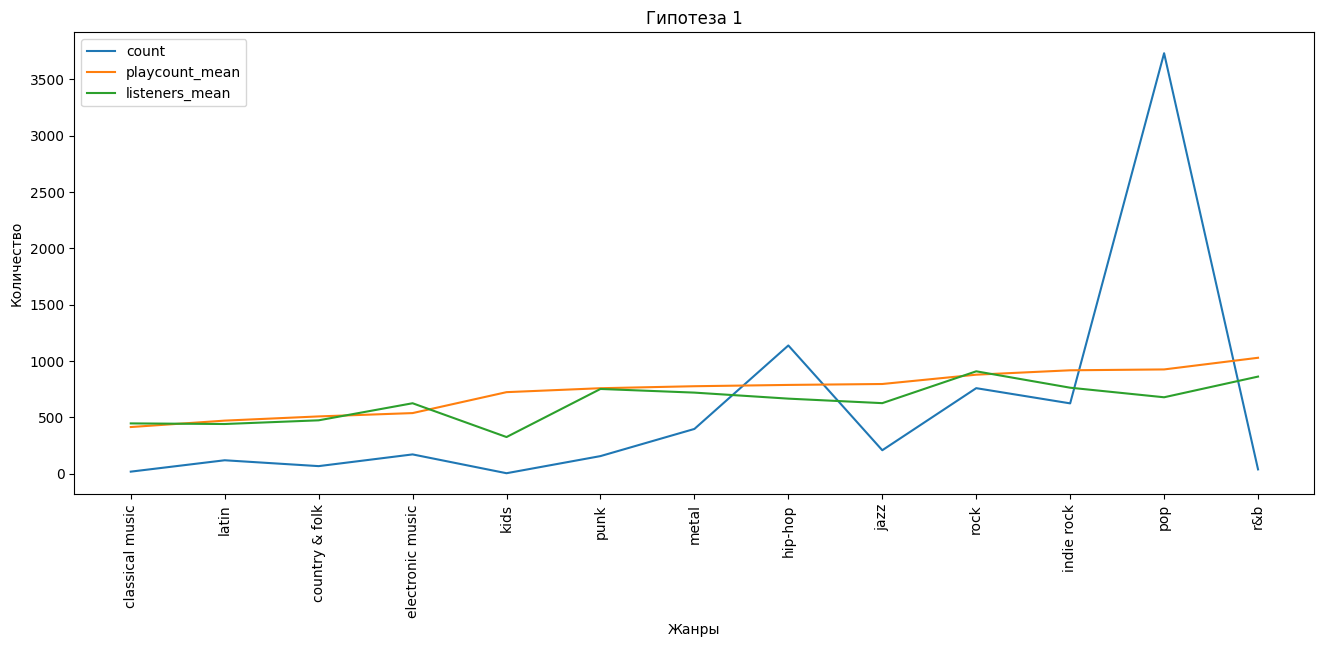

In [32]:
pplot = pd.DataFrame({"count": new_data['genre_kick'].value_counts(),
    "playcount_mean": new_data.groupby('genre_kick')['playcount'].mean()/10000,
    "listeners_mean": new_data.groupby('genre_kick')['listeners'].mean()/1000})
pplot = pplot.sort_values(by='playcount_mean')
pplot.plot(figsize=(16,6))
plt.ylabel("Количество")
plt.xlabel("Жанры")
plt.title("Гипотеза 1")
plt.xticks(range(len(pplot.index)), pplot.index, rotation=90)
plt.show()

Гипотеза подтвержена. Видим зависимость между всеми 3 параметрами. Определенные жанры чаще встречаются в топе, имеют больше прослушиваний и слушателей

Топ 15%:
r&b
pop

Антитоп 15%:
classsical music
latin

In [17]:
def duration_gr(sec):
  if sec<=60:
    return '0-1 min'
  if sec<=120:
    return '1-2 min'
  if sec<=180:
    return '2-3 min'
  if sec<=240:
    return '3-4 min'
  if sec<=300:
    return '4-5 min'
  return 'more 5 min'
data['duration'].apply(duration_gr)

,duration
0,2-3 min
1,2-3 min
2,2-3 min
3,1-2 min
4,2-3 min
...,...
9994,3-4 min
9995,0-1 min
9996,4-5 min
9997,3-4 min


In [18]:
data['duration_group'] = data['duration'].apply(duration_gr)
data

,Unnamed: 0,name,artist,playcount,listeners,duration,url,genres,top_genre,genre_kick,duration_group
0,0,Stateside + Zara Larsson,PinkPantheress,16644413,1092288,176,https://www.last.fm/music/PinkPantheress/_/Sta...,NaN,NaN,NaN,2-3 min
1,1,FATHER (feat. Travis Scott),Kanye West,1112155,277089,171,https://www.last.fm/music/Kanye+West/_/FATHER+...,NaN,NaN,NaN,2-3 min
2,2,KING,Kanye West,2065728,387318,126,https://www.last.fm/music/Kanye+West/_/KING,King;trap;outro;Skibidi Toilet;anti semetic,King,None,2-3 min
3,3,Babydoll,Dominic Fike,23069840,1549379,97,https://www.last.fm/music/Dominic+Fike/_/Babydoll,chill;alternative;pop;indie;alternative pop,chill,pop,1-2 min
4,4,SWIM,BTS,52676285,358110,159,https://www.last.fm/music/BTS/_/SWIM,NaN,NaN,NaN,2-3 min
...,...,...,...,...,...,...,...,...,...,...,...
9994,9994,on the street (with J. Cole),j-hope,32167631,349187,214,https://www.last.fm/music/j-hope/_/on+the+stre...,MORE;j-hope;JitB;Hip-Hop;Masterpiece,MORE,hip-hop,3-4 min
9995,9995,Lucid Dream,aespa,8183749,401679,0,https://www.last.fm/music/aespa/_/Lucid+Dream,contemporary rnb;rnb;k-pop;alternative rnb;fut...,contemporary rnb,pop,0-1 min
9996,9996,The View Between Villages - Extended,Noah Kahan,2432691,161048,292,https://www.last.fm/music/Noah+Kahan/_/The+Vie...,NaN,NaN,NaN,4-5 min
9997,9997,Sticker,NCT 127,4257357,244450,227,https://www.last.fm/music/NCT+127/_/Sticker,NaN,NaN,NaN,3-4 min


In [19]:
data['duration_group'].value_counts()

,count
duration_group,
3-4 min,4095
2-3 min,2106
4-5 min,1751
0-1 min,919
more 5 min,773
1-2 min,355


In [20]:
data.groupby('duration_group')['listeners'].mean().sort_values(ascending=False)/10000

,listeners
duration_group,
more 5 min,73.314333
4-5 min,73.106386
3-4 min,64.950458
2-3 min,51.194447
1-2 min,45.819553
0-1 min,31.056963


In [21]:
data.groupby('duration_group')['playcount'].mean().sort_values(ascending=False)/10000

,playcount
duration_group,
4-5 min,828.374685
3-4 min,805.517531
more 5 min,794.535737
2-3 min,737.038541
1-2 min,620.930594
0-1 min,364.408393


Text(0.5, 1.0, 'Гипотеза 2')

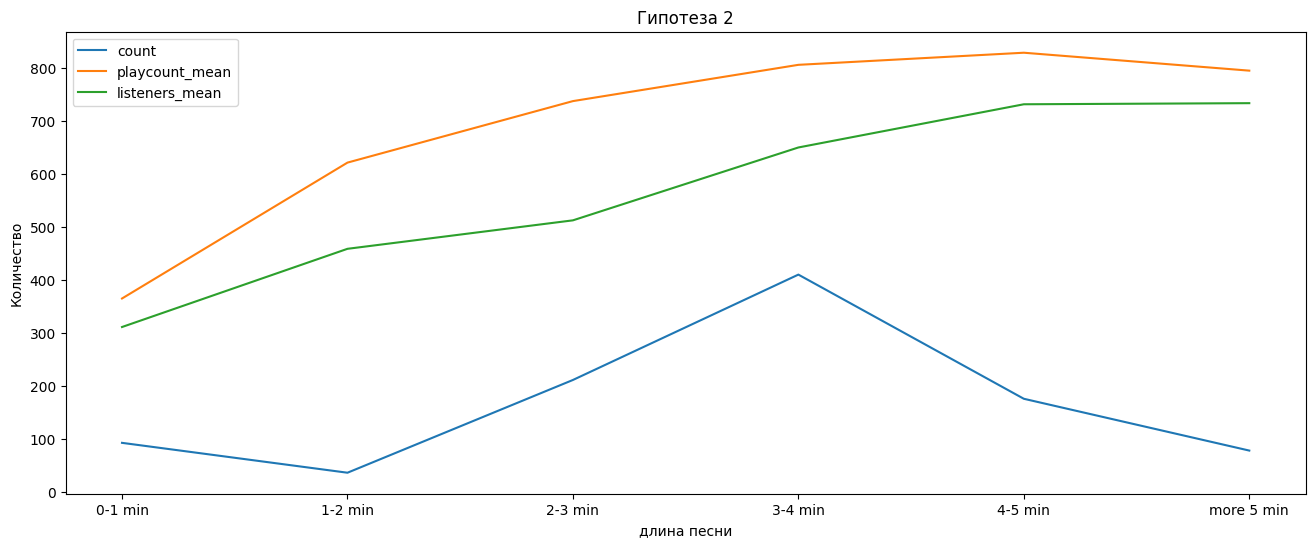

In [22]:
ppplot = pd.DataFrame({"count": data['duration_group'].value_counts()/10,
    "playcount_mean": data.groupby('duration_group')['playcount'].mean()/10000,
    "listeners_mean": data.groupby('duration_group')['listeners'].mean()/1000})
ppplot.plot(figsize=(16,6))
plt.ylabel("Количество")
plt.xlabel("длина песни")
plt.title("Гипотеза 2")

Гипотеза подтверждается. Самая лучшая длина, чтобы залететь в топ - это 4-5 минут (больше прослушиваний и слушателей) хоть и сама популярная это 3-4 минуты